### SIT307 8.1D – Sydney Housing Price Prediction

### Part 2: Data Understanding and Feature Engineering

This section explores the housing dataset, including price distributions,
differences between suburbs, time patterns, missing values and potential outliers.

In [27]:
%pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_excel("syd.xlsx")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (100, 13)


,id,suburb,address,sale_price,sale_date,property_type,bedrooms,bathrooms,parking,land_size,postcode,internal_area,source_url
0,1,Liverpool,"3 Secant Street, Liverpool",2000000,2026-09-15,House,4,2,2.0,676.0,2170,NaN,https://www.realestate.com.au/sold/property-ho...
1,2,Liverpool,"40 Maryvale Avenue, Liverpool",1200000,2026-09-15,House,3,1,1.0,701.9,2170,NaN,https://www.realestate.com.au/sold/property-ho...
2,3,Liverpool,"8/8-10 Lachlan Street, Liverpool",550000,2026-09-15,Unit,2,2,1.0,NaN,2170,NaN,https://www.realestate.com.au/sold/property-un...
3,4,Liverpool,"2/3-5 Nagle Street, Liverpool",480000,2026-09-14,Unit,2,1,1.0,NaN,2170,NaN,https://www.realestate.com.au/sold/property-un...
4,5,Liverpool,"41 Tully Avenue, Liverpool",1150000,2026-09-11,House,6,2,2.0,588.1,2170,NaN,https://www.realestate.com.au/sold/property-ho...


## 2. Data Quality and Initial Inspection

The dataset is checked for data types, missing values and duplicated records before analysis.

In [29]:
# Display column information
df.info()

# Count missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check duplicates
print("\nDuplicated rows:", df.duplicated().sum())
print("Duplicated addresses:", df["address"].duplicated().sum())
print("Duplicated source URLs:", df["source_url"].duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             100 non-null    int64         
 1   suburb         100 non-null    object        
 2   address        100 non-null    object        
 3   sale_price     100 non-null    int64         
 4   sale_date      100 non-null    datetime64[ns]
 5   property_type  100 non-null    object        
 6   bedrooms       100 non-null    int64         
 7   bathrooms      100 non-null    int64         
 8   parking        98 non-null     float64       
 9   land_size      41 non-null     float64       
 10  postcode       100 non-null    int64         
 11  internal_area  18 non-null     float64       
 12  source_url     100 non-null    object        
dtypes: datetime64[ns](1), float64(3), int64(5), object(4)
memory usage: 10.3+ KB

Missing values:
id                0
suburb      

## 3. Dataset Composition and Descriptive Statistics

This section examines the number of properties in each suburb, the distribution
of property types and the main descriptive statistics of the numerical features.

In [30]:
# Number of properties in each suburb
print("Properties by suburb:")
print(df["suburb"].value_counts())

# Number of properties by type
print("\nProperties by type:")
print(df["property_type"].value_counts())

# Date range
print("\nSale date range:")
print(df["sale_date"].min(), "to", df["sale_date"].max())

# Summary statistics
df[
    [
        "sale_price",
        "bedrooms",
        "bathrooms",
        "parking",
        "land_size",
        "internal_area"
    ]
].describe().round(2)

Properties by suburb:
suburb
Liverpool    35
Burwood      34
Chatswood    31
Name: count, dtype: int64

Properties by type:
property_type
House        40
Apartment    35
Unit         14
Duplex        7
Townhouse     4
Name: count, dtype: int64

Sale date range:
2025-11-10 00:00:00 to 2026-09-15 00:00:00


,sale_price,bedrooms,bathrooms,parking,land_size,internal_area
count,100.00,100.00,100.00,98.00,41.00,18.00
mean,1821404.00,2.82,1.73,1.49,463.04,95.67
std,1342660.52,1.20,0.86,0.89,227.75,21.83
min,350000.00,1.00,1.00,1.00,157.00,59.00
25%,651250.00,2.00,1.00,1.00,306.50,79.50
50%,1559000.00,3.00,2.00,1.00,401.30,93.00
75%,2492250.00,3.00,2.00,2.00,588.10,110.75
max,6200000.00,6.00,5.00,5.00,1167.00,132.00


## 4. Distribution of Sale Prices

The distribution of sale prices is examined to identify its overall shape, spread, skewness and potentially unusual observations.

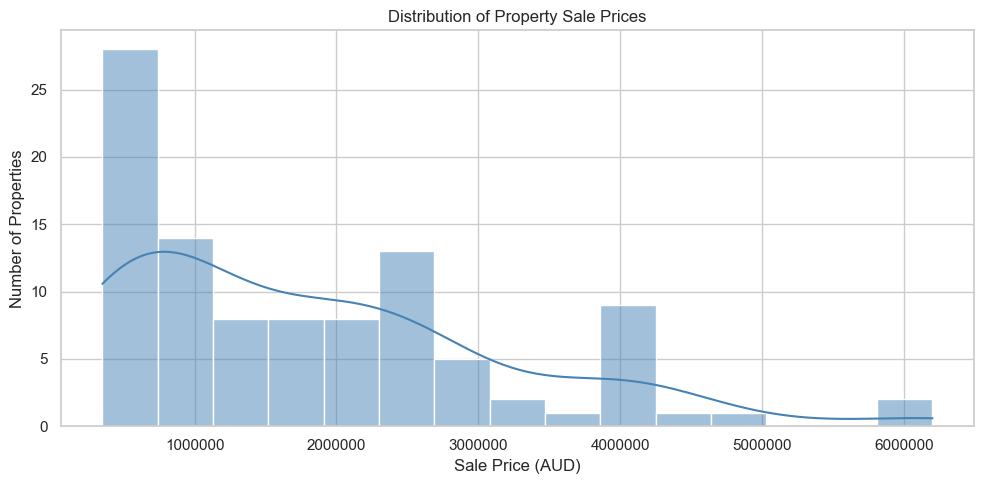

Sale price skewness: 1.08


In [31]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="sale_price",
    bins=15,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Property Sale Prices")
plt.xlabel("Sale Price (AUD)")
plt.ylabel("Number of Properties")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

print("Sale price skewness:", round(df["sale_price"].skew(), 2))

### Interpretation

The distribution of sale prices is positively skewed, with a skewness value of 1.08. Most properties are concentrated in the lower and middle price ranges, while a smaller number of properties have substantially higher sale prices. The long right tail suggests the presence of expensive properties that should be examined as potential outliers. These observations should not be removed automatically because they may represent valid differences between the three housing markets.

### 5. Sale Price Comparison Between Suburbs

A boxplot is used to compare sale-price distributions across Liverpool, Burwood and Chatswood, including their median prices, variability and potential outliers.

/var/folders/kt/t4knj79d58d3gjmrpcq490nm0000gn/T/ipykernel_5798/1098888965.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


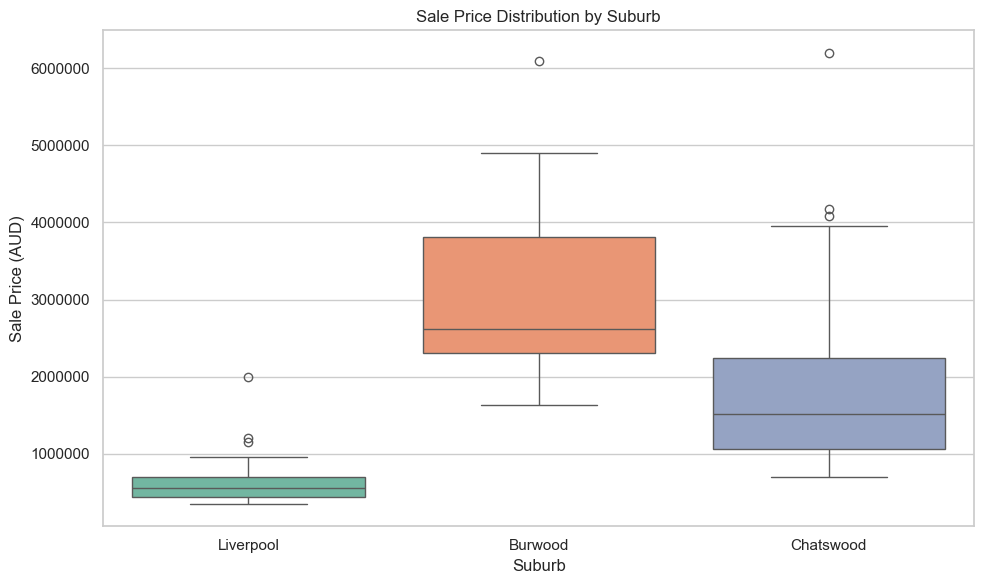

,count,mean,median,minimum,maximum
suburb,,,,,
Burwood,34,2964676.47,2621000.0,1630000,6095000
Chatswood,31,1901109.68,1518000.0,700000,6200000
Liverpool,35,640200.00,550000.0,350000,2000000


In [32]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="suburb",
    y="sale_price",
    order=["Liverpool", "Burwood", "Chatswood"],
    palette="Set2"
)

plt.title("Sale Price Distribution by Suburb")
plt.xlabel("Suburb")
plt.ylabel("Sale Price (AUD)")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

suburb_prices = df.groupby("suburb")["sale_price"].agg(
    count="count",
    mean="mean",
    median="median",
    minimum="min",
    maximum="max"
).round(2)

suburb_prices

### Approach and Outcomes

To investigate whether location is associated with property prices, sale-price distributions were compared across Liverpool, Burwood and Chatswood using a boxplot and suburb-level descriptive statistics. The median was considered alongside the mean because the distributions contain high-value properties that may pull the mean upward.

The analysis revealed substantial differences between the three housing markets. Burwood had the highest median sale price at $2,621,000 and a mean of $2,964,676.47. Chatswood followed with a median of $1,518,000 and a higher mean of $1,901,109.68. Liverpool was considerably more affordable, with a median of $550,000 and a mean of $640,200. Therefore, suburb appears likely to be an important predictor of sale price.

Chatswood showed particularly high variability, with prices ranging from $700,000 to $6,200,000. Burwood ranged from $1,630,000 to $6,095,000, while Liverpool had a narrower range from $350,000 to $2,000,000. In all three suburbs, the mean exceeded the median, indicating that expensive properties increased the averages. The boxplot also identified potential outliers. These observations will be examined using the IQR method and verified against their property information rather than being removed automatically, because they may represent legitimate differences in property type, size or market location.

## 6. Investigation of Potential Price Outliers

The IQR method is applied separately within each suburb to identify unusually priced properties. A suburb-level approach is more appropriate than calculating one threshold for the complete dataset because the three suburbs represent substantially different price markets. Properties below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are flagged for investigation rather than removed automatically.

In [33]:
outlier_results = []

for suburb in df["suburb"].unique():
    suburb_data = df[df["suburb"] == suburb].copy()

    q1 = suburb_data["sale_price"].quantile(0.25)
    q3 = suburb_data["sale_price"].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    suburb_outliers = suburb_data[
        (suburb_data["sale_price"] < lower_bound) |
        (suburb_data["sale_price"] > upper_bound)
    ].copy()

    suburb_outliers["lower_bound"] = lower_bound
    suburb_outliers["upper_bound"] = upper_bound

    outlier_results.append(suburb_outliers)

price_outliers = pd.concat(outlier_results)

price_outliers[
    [
        "id",
        "suburb",
        "address",
        "sale_price",
        "property_type",
        "bedrooms",
        "bathrooms",
        "land_size",
        "lower_bound",
        "upper_bound"
    ]
].sort_values(["suburb", "sale_price"])

,id,suburb,address,sale_price,property_type,bedrooms,bathrooms,land_size,lower_bound,upper_bound
46,47,Burwood,"11 Selborne Street, Burwood",6095000,House,6,3,1163.0,52500.0,6068500.0
92,93,Chatswood,"10 Holland Street, Chatswood",4080000,House,3,2,657.6,-715000.0,4005000.0
93,94,Chatswood,"31 Royal Street, Chatswood",4180000,House,5,3,NaN,-715000.0,4005000.0
72,73,Chatswood,"11 Crick Street, Chatswood",6200000,House,5,3,746.1,-715000.0,4005000.0
4,5,Liverpool,"41 Tully Avenue, Liverpool",1150000,House,6,2,588.1,37500.0,1089500.0
1,2,Liverpool,"40 Maryvale Avenue, Liverpool",1200000,House,3,1,701.9,37500.0,1089500.0
0,1,Liverpool,"3 Secant Street, Liverpool",2000000,House,4,2,676.0,37500.0,1089500.0


### Approach and Outcomes

The suburb-specific IQR analysis identified seven potential price outliers. In Liverpool, 41 Tully Avenue ($1,150,000), 40 Maryvale Avenue ($1,200,000), and 3 Secant Street ($2,000,000) exceeded the suburb’s upper threshold of $1,089,500. These observations are all houses, whereas Liverpool contains many lower-priced units and apartments. Their larger land sizes and housing characteristics may therefore explain why their prices are unusually high relative to the Liverpool sample.

In Chatswood, 10 Holland Street ($4,080,000), 31 Royal Street ($4,180,000), and 11 Crick Street ($6,200,000) exceeded the upper threshold of $4,005,000. The most extreme property, 11 Crick Street, contains five bedrooms and 746.1 square metres of land, providing a plausible explanation for its high price. However, the land size for 31 Royal Street is missing, limiting the ability to explain its value fully.

In Burwood, 11 Selborne Street sold for $6,095,000, only $26,500 above the calculated upper threshold of $6,068,500. It also has six bedrooms, three bathrooms and 1,163 square metres of land, suggesting that it represents a genuinely large premium property rather than an obvious data-entry error.

These properties will be retained provisionally because the IQR method identifies statistical rarity, not incorrect data. Removing valid premium properties would reduce the model’s ability to represent the upper end of each housing market. Their source listings should nevertheless be verified before modelling.

### 7. Property Type and Sale Price

Property type may influence sale price because houses, apartments, units, townhouses and duplexes differ in land ownership, size and market demand. First, the distribution of property types across suburbs is examined to identify sampling imbalance. Median prices are then compared because they are less sensitive to the high-value outliers identified previously.

Property type distribution by suburb:


property_type,Apartment,Duplex,House,Townhouse,Unit
suburb,,,,,
Burwood,0,6,28,0,0
Chatswood,20,1,7,1,2
Liverpool,15,0,5,3,12


Sale price summary by property type:


,count,mean,median,minimum,maximum
property_type,,,,,
House,40,2953100.0,2621000.0,870000,6200000
Duplex,7,2475000.0,2303000.0,1630000,3950000
Townhouse,4,1016750.0,918500.0,770000,1460000
Apartment,35,940240.0,751000.0,385000,2450000
Unit,14,694000.0,570000.0,350000,1742000


/var/folders/kt/t4knj79d58d3gjmrpcq490nm0000gn/T/ipykernel_5798/2015972805.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


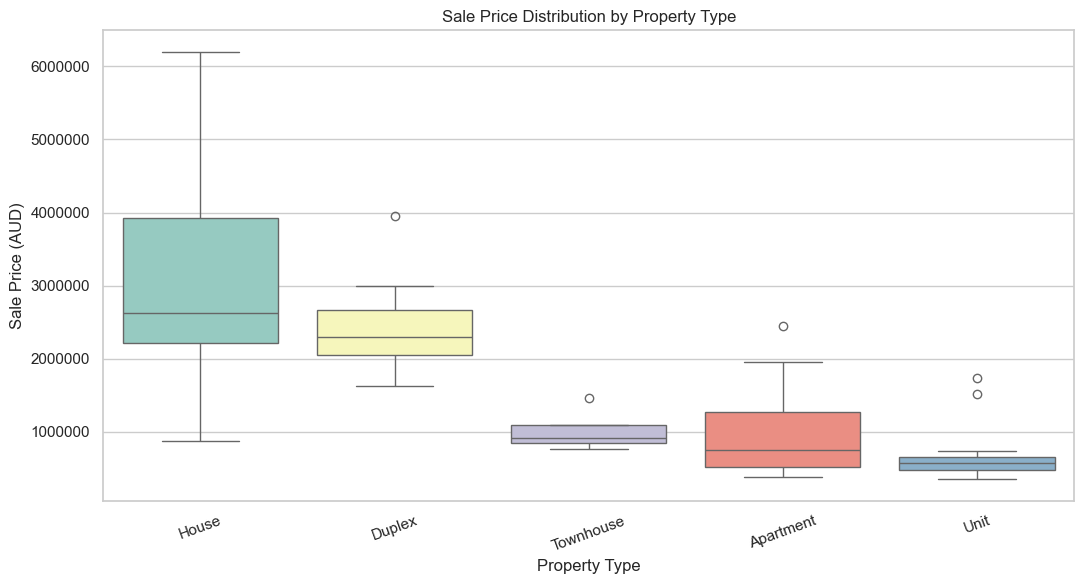

In [34]:
# Number of each property type within each suburb
property_type_counts = pd.crosstab(
    df["suburb"],
    df["property_type"]
)

print("Property type distribution by suburb:")
display(property_type_counts)

# Price summary for each property type
property_type_prices = df.groupby("property_type")["sale_price"].agg(
    count="count",
    mean="mean",
    median="median",
    minimum="min",
    maximum="max"
).round(2).sort_values("median", ascending=False)

print("Sale price summary by property type:")
display(property_type_prices)

# Visual comparison
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df,
    x="property_type",
    y="sale_price",
    order=property_type_prices.index,
    palette="Set3"
)

plt.title("Sale Price Distribution by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Sale Price (AUD)")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [35]:
hue="property_type",
legend=False,

<Axes: xlabel='property_type', ylabel='sale_price'>

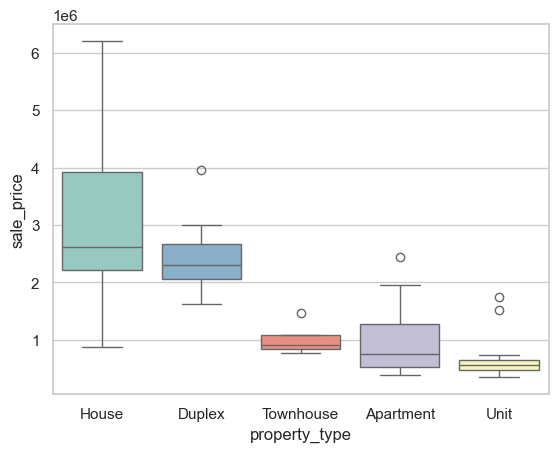

In [36]:
sns.boxplot(
    data=df,
    x="property_type",
    y="sale_price",
    hue="property_type",
    order=property_type_prices.index,
    palette="Set3",
    legend=False
)

### Approach and Outcomes

A cross-tabulation was used to examine whether property types were represented consistently across the three suburbs. Median and mean sale prices were then calculated for each property type, and a boxplot was used to compare their distributions. The median was emphasised because several high-value properties could inflate the mean.

Houses recorded the highest median sale price at $2,621,000, followed by duplexes at $2,303,000. Townhouses had a median of $918,500, apartments $751,000, and units $570,000. Houses also displayed the widest price range, from $870,000 to $6,200,000. These results suggest that property type may provide useful predictive information because detached houses and duplexes generally sell for more than higher-density properties.

However, the cross-tabulation revealed substantial sampling imbalance. Burwood contained 28 houses and six duplexes, with no apartments, units or townhouses. In contrast, Chatswood contained 20 apartments but only seven houses, while Liverpool contained 15 apartments, 12 units and only five houses. Therefore, the observed relationship between property type and price is partly confounded with suburb. For example, the high median for houses may reflect the concentration of houses in expensive Burwood rather than property type alone.

Consequently, both suburb and property type should be retained as separate predictors. Their possible interaction should also be considered during feature engineering, while results for sparsely represented categories such as townhouses and duplexes should be interpreted cautiously.

### 8. Sale Price Trends Over Time

Monthly median sale prices are examined separately for each suburb to explore whether prices changed during the collection period. The median is used instead of the mean to reduce the influence of high-value outliers. Monthly sample counts are also reported because months containing only a small number of sales may produce unstable estimates.

,sale_month,suburb,median_price,number_of_sales
0,2025-11-01,Burwood,2471500.0,6
1,2025-12-01,Burwood,3350000.0,2
2,2026-01-01,Burwood,1630000.0,1
3,2026-02-01,Burwood,2050000.0,3
4,2026-03-01,Burwood,3325000.0,8
5,2026-04-01,Burwood,3150000.0,6
6,2026-04-01,Chatswood,1500000.0,4
7,2026-05-01,Burwood,2765000.0,1
8,2026-05-01,Chatswood,1500000.0,11
9,2026-06-01,Burwood,2642000.0,1


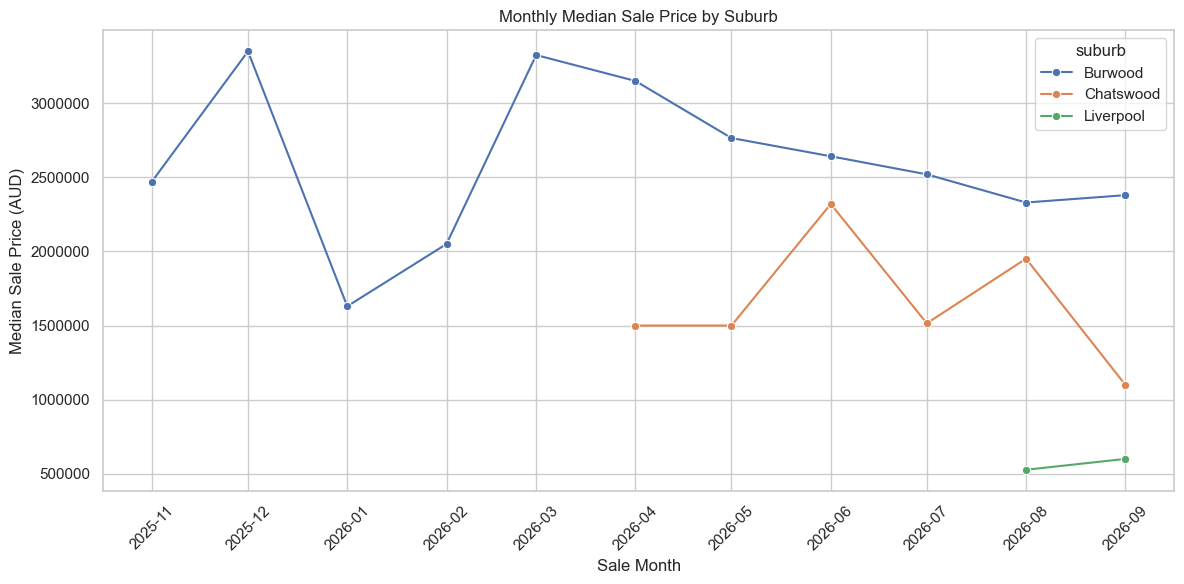

In [37]:
# Create a month variable without changing the original sale date
df["sale_month"] = df["sale_date"].dt.to_period("M").dt.to_timestamp()

monthly_prices = (
    df.groupby(["sale_month", "suburb"])
      .agg(
          median_price=("sale_price", "median"),
          number_of_sales=("sale_price", "count")
      )
      .reset_index()
)

display(monthly_prices)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_prices,
    x="sale_month",
    y="median_price",
    hue="suburb",
    marker="o"
)

plt.title("Monthly Median Sale Price by Suburb")
plt.xlabel("Sale Month")
plt.ylabel("Median Sale Price (AUD)")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Approach and Outcomes

To investigate temporal patterns, sale dates were converted into monthly periods and the median sale price was calculated separately for each suburb. The median was selected because the sale-price distribution is positively skewed and contains several high-value properties that could substantially influence the monthly mean. The number of sales in each suburb-month was also calculated to assess whether each monthly estimate was supported by an adequate sample.

The figure shows that Burwood maintained the highest monthly median prices throughout its observed period, although its values fluctuated considerably. Its median increased to approximately $3.3 million in December 2025, declined to about $1.6 million in January 2026, recovered to approximately $3.3 million in March, and then generally declined to around $2.4 million by September 2026. Chatswood displayed lower but still variable monthly medians, including a peak of approximately $2.3 million in June 2026 before falling to about $1.1 million in September. Liverpool remained the least expensive suburb, with observed monthly medians of approximately $520,000 in August and $600,000 in September 2026.

These fluctuations should not be interpreted as conclusive changes in the broader housing market. The suburbs do not have equal coverage across time: Burwood is represented across most of the collection period, Chatswood appears only in the later months, and Liverpool is concentrated in August and September 2026. Some monthly medians are also based on very few transactions; for example, the displayed table shows only one Chatswood sale in September. Consequently, changes in property type, size and quality between months may explain part of the observed movement. Sale month may still be retained as a potential predictor, but its effect must be interpreted cautiously because time and suburb are partly confounded in this manually collected sample.

### 9. Relationships Between Numerical Features and Sale Price

This analysis examines how sale price is associated with bedrooms, bathrooms, parking spaces, land size and internal area. Correlations and visualisations are used to identify potentially useful predictors. Results involving land size and internal area must be interpreted cautiously because these variables contain substantial missing data.

,sale_price,bedrooms,bathrooms,parking,land_size,internal_area
sale_price,1.00,0.76,0.57,0.49,0.53,0.26
bedrooms,0.76,1.00,0.64,0.51,0.43,0.55
bathrooms,0.57,0.64,1.00,0.26,0.06,0.71
parking,0.49,0.51,0.26,1.00,0.38,0.19
land_size,0.53,0.43,0.06,0.38,1.00,NaN
internal_area,0.26,0.55,0.71,0.19,NaN,1.00


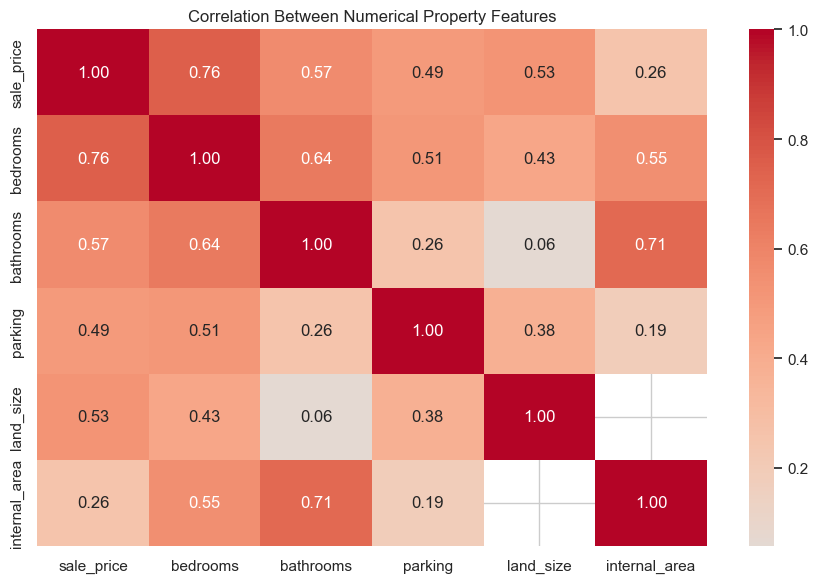

In [38]:
numeric_features = [
    "sale_price",
    "bedrooms",
    "bathrooms",
    "parking",
    "land_size",
    "internal_area"
]

correlation_matrix = df[numeric_features].corr()

display(correlation_matrix.round(2))

plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Numerical Property Features")
plt.tight_layout()
plt.show()

### Approach and Outcomes

Pearson correlation was used to examine the direction and strength of the linear relationships between sale price and the available numerical property features. The heatmap was used to make the relative strength of these relationships easier to compare. Correlation indicates association rather than causation, and the results may also reflect differences between suburbs and property types.

Bedrooms had the strongest positive correlation with sale price (r = 0.76), suggesting that properties with more bedrooms generally sold for higher prices. Bathrooms showed a moderate positive correlation of 0.57, followed by land size at 0.53 and parking at 0.49. Internal area had the weakest observed relationship with sale price (r = 0.26). These results initially suggest that bedrooms may be the most informative numerical predictor of price.

However, the correlations must be interpreted cautiously. Bedrooms and bathrooms were themselves correlated (r = 0.64), meaning that both variables partly represent the overall size and capacity of a property. Furthermore, expensive Burwood properties are mainly houses with more bedrooms, while Liverpool and Chatswood contain larger proportions of apartments and units. Therefore, the strong bedroom-price relationship may partly reflect suburb and property-type differences rather than an independent bedroom effect.

Missing data also limits the reliability of some coefficients. Land size was available for only 41 properties, while internal area was available for only 18. No correlation could be calculated between land size and internal area because there were insufficient observations containing both values, producing the NaN result. Therefore, these two variables should not be treated as equally reliable as bedrooms or bathrooms. Before modelling, the missing values will require a justified treatment strategy, and the numerical relationships should be examined alongside suburb and property type.

 ### 10. Selection of the Three Most Influential Variables

Before creating engineered features, the three variables expected to have the strongest influence on sale price are suburb, property type and number of bedrooms.

1. **Suburb:** Location produced the clearest price differences. The median sale prices were $2,621,000 in Burwood, $1,518,000 in Chatswood and $550,000 in Liverpool. Suburb therefore captures major differences between the three housing markets.

2. **Property type:** Houses had the highest median price of $2,621,000, followed by duplexes at $2,303,000, while apartments and units had substantially lower medians of $751,000 and $570,000. Property type represents differences in land ownership, space and housing density. However, its effect is partly confounded with suburb because the property-type composition differs substantially between locations.

3. **Bedrooms:** Bedrooms had the strongest numerical correlation with sale price (r = 0.76). This suggests that property capacity and size are important, although part of this relationship may also reflect the concentration of larger houses in the more expensive suburbs.

Land size was not selected despite its moderate correlation with price (r = 0.53) because it was missing for 59 properties. Internal area was also excluded from the three strongest variables because it was available for only 18 properties and had a weak correlation with price (r = 0.26).

## 11. Feature Engineering

New features are created to represent property capacity, temporal position, missing-information patterns and the interaction between location and property type. The original variables are retained so that the usefulness of the engineered features can later be evaluated during modelling.

In [39]:
# Create a separate feature-engineered dataset
df_fe = df.copy()

# Combined measure of property capacity
df_fe["total_rooms"] = (
    df_fe["bedrooms"] + df_fe["bathrooms"]
)

# Number of months since the earliest sale in the dataset
first_month = df_fe["sale_date"].min().to_period("M")

df_fe["months_since_start"] = df_fe["sale_date"].apply(
    lambda date: (
        (date.to_period("M").year - first_month.year) * 12
        + date.to_period("M").month
        - first_month.month
    )
)

# Interaction between location and property type
df_fe["suburb_property_type"] = (
    df_fe["suburb"] + "_" + df_fe["property_type"]
)

# Indicators showing whether important size information is missing
df_fe["land_size_missing"] = df_fe["land_size"].isna().astype(int)
df_fe["internal_area_missing"] = df_fe["internal_area"].isna().astype(int)

engineered_features = [
    "suburb",
    "property_type",
    "bedrooms",
    "bathrooms",
    "total_rooms",
    "months_since_start",
    "suburb_property_type",
    "land_size_missing",
    "internal_area_missing"
]

display(df_fe[engineered_features].head(10))

print("Original dataset shape:", df.shape)
print("Feature-engineered dataset shape:", df_fe.shape)

,suburb,property_type,bedrooms,bathrooms,total_rooms,months_since_start,suburb_property_type,land_size_missing,internal_area_missing
0,Liverpool,House,4,2,6,10,Liverpool_House,0,1
1,Liverpool,House,3,1,4,10,Liverpool_House,0,1
2,Liverpool,Unit,2,2,4,10,Liverpool_Unit,1,1
3,Liverpool,Unit,2,1,3,10,Liverpool_Unit,1,1
4,Liverpool,House,6,2,8,10,Liverpool_House,0,1
5,Liverpool,Unit,2,2,4,10,Liverpool_Unit,1,1
6,Liverpool,Unit,2,2,4,10,Liverpool_Unit,1,0
7,Liverpool,Apartment,2,2,4,10,Liverpool_Apartment,1,0
8,Liverpool,Townhouse,3,1,4,10,Liverpool_Townhouse,0,1
9,Liverpool,Apartment,1,1,2,9,Liverpool_Apartment,1,0


Original dataset shape: (100, 14)
Feature-engineered dataset shape: (100, 19)


### Approach and Outcomes

Feature engineering was performed on a copy of the dataset to preserve the original data. Five new features were created based on the findings from the exploratory analysis.

First, `total_rooms` combines bedrooms and bathrooms to represent the overall accommodation capacity of a property. This was justified because bedrooms and bathrooms were both positively associated with sale price and were themselves correlated. However, the original variables were retained because bedrooms and bathrooms may influence value differently.

Second, `months_since_start` converts the sale date into a numerical measure of time. This format can be used by predictive models more easily than the original date. Its interpretation must remain cautious because the three suburbs were not represented equally across the collection period.

Third, `suburb_property_type` captures the interaction between location and property type. This was created because property types were distributed unevenly across the suburbs. For example, Burwood contained mainly houses and duplexes, while Chatswood and Liverpool contained more apartments and units. Therefore, the value associated with a property type may differ between locations.

Finally, `land_size_missing` and `internal_area_missing` record whether these measurements were unavailable. This preserves potentially useful information about the pattern of missingness without assuming that an unknown value equals zero. The resulting dataset contains 19 columns compared with 14 immediately before feature engineering.

These decisions align with the initial understanding that location, housing type and property capacity influence sale prices. Nevertheless, the engineered variables must be evaluated during modelling rather than assumed to improve prediction automatically.

In [40]:
engineered_numeric_features = [
    "sale_price",
    "total_rooms",
    "months_since_start",
    "land_size_missing",
    "internal_area_missing"
]

engineered_correlations = (
    df_fe[engineered_numeric_features]
    .corr()["sale_price"]
    .sort_values(ascending=False)
)

print("Correlation of engineered features with sale price:")
display(engineered_correlations.round(2))

print("\nSuburb-property type combinations:")
display(
    df_fe["suburb_property_type"]
    .value_counts()
    .rename("number_of_properties")
    .to_frame()
)

Correlation of engineered features with sale price:


sale_price               1.00
total_rooms              0.74
internal_area_missing    0.35
months_since_start      -0.53
land_size_missing       -0.58
Name: sale_price, dtype: float64


Suburb-property type combinations:


,number_of_properties
suburb_property_type,
Burwood_House,28
Chatswood_Apartment,20
Liverpool_Apartment,15
Liverpool_Unit,12
Chatswood_House,7
Burwood_Duplex,6
Liverpool_House,5
Liverpool_Townhouse,3
Chatswood_Unit,2


### 12. Model Selection and Expected Performance

Three regression models were selected to represent different modelling approaches: Linear Regression, Random Forest Regressor and Gradient Boosting Regressor. The dataset contains only 100 properties and includes numerical variables, categorical variables, missing values and possible nonlinear relationships. Therefore, comparing models with different levels of complexity can show whether additional complexity improves prediction or causes overfitting.

### Linear Regression

Linear Regression was selected as a simple and interpretable baseline model. It estimates sale price by modelling a linear relationship between the predictors and the target. One advantage is that its coefficients can help explain how features such as suburb, property type and number of rooms are associated with the predicted price. It is also less likely to overfit a small dataset than more complex models. However, it assumes that the effects of the predictors are approximately linear and additive, so it may underfit if housing prices depend on complex nonlinear relationships or interactions.

### Random Forest Regressor

Random Forest was selected as a nonlinear ensemble model. It combines predictions from many decision trees and can capture relationships and interactions that Linear Regression may miss. This is relevant because the analysis showed that suburb and property type are related and are not represented equally across the sample. The model used 300 trees to produce stable combined predictions. Its maximum depth was limited to 5 and the minimum number of samples in each leaf was set to 2 to reduce the risk of creating overly specific trees. Random Forest may still overfit because the dataset contains only 100 properties, and its predictions are less straightforward to interpret than those of Linear Regression.

### Gradient Boosting Regressor

Gradient Boosting was selected as a second ensemble approach. Unlike Random Forest, which builds multiple trees more independently, Gradient Boosting builds trees sequentially so that each new tree attempts to correct the errors made by the earlier trees. This may allow it to model difficult nonlinear patterns and interactions between suburb, property type and property size. The model used 100 estimators with a low learning rate of 0.05 so that improvements were made gradually. Tree depth was limited to 2 and the minim


### 13. Data Preparation for Modelling

## 13. Data Preparation for Modelling

The target variable for the modelling task is `sale_price`. Columns that act only as identifiers or references, including `id`, `address` and `source_url`, were excluded because they are not suitable general predictors of property value. The original `sale_date` was also excluded after creating the numerical feature `months_since_start`. Postcode was not used because each postcode corresponds directly to one of the three selected suburbs, meaning that it would repeat the location information already represented by `suburb`.

The numerical predictors selected for modelling were `bedrooms`, `bathrooms`, `parking`, `land_size`, `internal_area`, `total_rooms`, `months_since_start`, `land_size_missing` and `internal_area_missing`. The categorical predictors were `suburb`, `property_type` and `suburb_property_type`. This produced a predictor dataset containing 100 observations and 12 original predictor columns before preprocessing.

The dataset contains two missing values in `parking`, 59 in `land_size` and 82 in `internal_area`. Numerical missing values were replaced using the median calculated from each training fold. Median imputation was selected because it is less affected by extreme property values than mean imputation. The missing-value indicators were retained because the absence of land or internal-area information may be related to property type and may therefore contain useful predictive information.

Numerical variables were standardised so that features measured on different scales could be processed consistently. Categorical variables were transformed using one-hot encoding because the models require numerical inputs and the categories do not have a natural numerical order. Unknown categories were ignored so that the pipeline could process a category appearing in a validation fold without failing.

All preprocessing operations were placed inside a modelling pipeline. This ensured that imputation, scaling and encoding were fitted only on the training portion of each cross-validation fold. Therefore, information from the validation observations was not used during preprocessing or model training, reducing the risk of data leakage.

### Potential Feature Redundancy

Including `suburb`, `property_type` and their interaction feature, `suburb_property_type`, together introduces some information redundancy because the interaction already combines the two original variables. This may contribute to multicollinearity, particularly affecting the stability and interpretation of the Linear Regression coefficients. The interaction was retained because it may capture differences in how property types are valued across the three suburbs. However, the individual Linear Regression coefficients should be interpreted cautiously. Future work could compare performance with and without the interaction feature or use a regularised model, such as Ridge Regression, to reduce the effect of multicollinearity.


In [41]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Target variable
y = df_fe["sale_price"]

# Numerical predictors
numeric_model_features = [
    "bedrooms",
    "bathrooms",
    "parking",
    "land_size",
    "internal_area",
    "total_rooms",
    "months_since_start",
    "land_size_missing",
    "internal_area_missing"
]

# Categorical predictors
categorical_model_features = [
    "suburb",
    "property_type",
    "suburb_property_type"
]

# Predictor dataset
X = df_fe[
    numeric_model_features + categorical_model_features
].copy()

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Apply the correct preprocessing to each column type
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_model_features),
        ("categorical", categorical_transformer, categorical_model_features)
    ]
)

print("Predictor dataset shape:", X.shape)
print("Target shape:", y.shape)
print("\nPredictor columns:")
print(X.columns.tolist())
print("\nMissing values before pipeline preprocessing:")
display(X.isna().sum())

Predictor dataset shape: (100, 12)
Target shape: (100,)

Predictor columns:
['bedrooms', 'bathrooms', 'parking', 'land_size', 'internal_area', 'total_rooms', 'months_since_start', 'land_size_missing', 'internal_area_missing', 'suburb', 'property_type', 'suburb_property_type']

Missing values before pipeline preprocessing:


bedrooms                  0
bathrooms                 0
parking                   2
land_size                59
internal_area            82
total_rooms               0
months_since_start        0
land_size_missing         0
internal_area_missing     0
suburb                    0
property_type             0
suburb_property_type      0
dtype: int64

### 14. Five-Fold Cross-Validation

Five-fold cross-validation is used because the dataset contains only 100 observations. In each iteration, approximately 80 properties are used for training and 20 for validation. This process is repeated five times so that every property is used for validation once. Shuffling is enabled with a fixed random state to make the experiment reproducible.

The same preprocessing and folds are used for all three models to ensure a fair comparison. Performance is measured using MAE, RMSE and R². MAE represents the average absolute prediction error in Australian dollars. RMSE gives greater weight to large errors, which is important when expensive properties are predicted poorly. R² measures the proportion of price variation explained by the model.

The training metrics are also recorded. A large difference between training and validation performance may indicate overfitting, while weak performance on both sets may indicate underfitting.

The model settings were fixed before evaluation. Random Forest uses 300 trees to produce stable averaged predictions, while limiting tree depth and leaf size reduces overfitting. Gradient Boosting uses a low learning rate, shallow trees and a minimum leaf size to control complexity on the small dataset. These settings provide a reasonable comparison without performing extensive hyperparameter tuning on the same limited sample.

In [42]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Models with fixed settings
models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=2,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=2,
        min_samples_leaf=3,
        random_state=42
    )
}

# Same five folds for every model
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Regression evaluation metrics
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

model_results = []
fold_results = {}

for model_name, model in models.items():

    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    scores = cross_validate(
        model_pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=True
    )

    fold_results[model_name] = scores

    model_results.append({
        "Model": model_name,

        "Train MAE": -scores["train_MAE"].mean(),
        "Validation MAE": -scores["test_MAE"].mean(),
        "Validation MAE SD": scores["test_MAE"].std(),

        "Train RMSE": -scores["train_RMSE"].mean(),
        "Validation RMSE": -scores["test_RMSE"].mean(),
        "Validation RMSE SD": scores["test_RMSE"].std(),

        "Train R2": scores["train_R2"].mean(),
        "Validation R2": scores["test_R2"].mean(),
        "Validation R2 SD": scores["test_R2"].std()
    })

results_df = pd.DataFrame(model_results)

display(
    results_df.round({
        "Train MAE": 0,
        "Validation MAE": 0,
        "Validation MAE SD": 0,
        "Train RMSE": 0,
        "Validation RMSE": 0,
        "Validation RMSE SD": 0,
        "Train R2": 3,
        "Validation R2": 3,
        "Validation R2 SD": 3
    })
)

,Model,Train MAE,Validation MAE,Validation MAE SD,Train RMSE,Validation RMSE,Validation RMSE SD,Train R2,Validation R2,Validation R2 SD
0,Linear Regression,284627.0,395699.0,41135.0,403455.0,558098.0,60658.0,0.907,0.764,0.120
1,Random Forest,225359.0,409033.0,96660.0,353699.0,642877.0,155301.0,0.929,0.710,0.131
2,Gradient Boosting,208771.0,367374.0,95765.0,301252.0,573253.0,154178.0,0.947,0.758,0.139


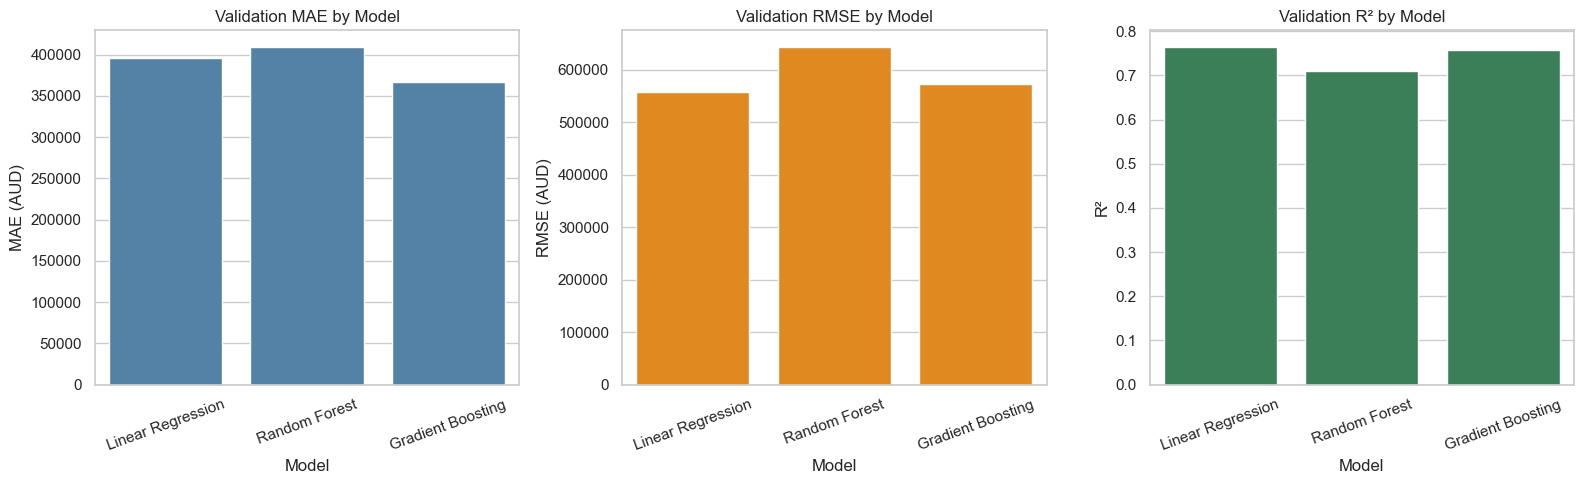

In [43]:
# Compare validation performance visually
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Validation MAE",
    ax=axes[0],
    color="steelblue"
)
axes[0].set_title("Validation MAE by Model")
axes[0].set_ylabel("MAE (AUD)")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=results_df,
    x="Model",
    y="Validation RMSE",
    ax=axes[1],
    color="darkorange"
)
axes[1].set_title("Validation RMSE by Model")
axes[1].set_ylabel("RMSE (AUD)")
axes[1].tick_params(axis="x", rotation=20)

sns.barplot(
    data=results_df,
    x="Model",
    y="Validation R2",
    ax=axes[2],
    color="seagreen"
)
axes[2].set_title("Validation R² by Model")
axes[2].set_ylabel("R²")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

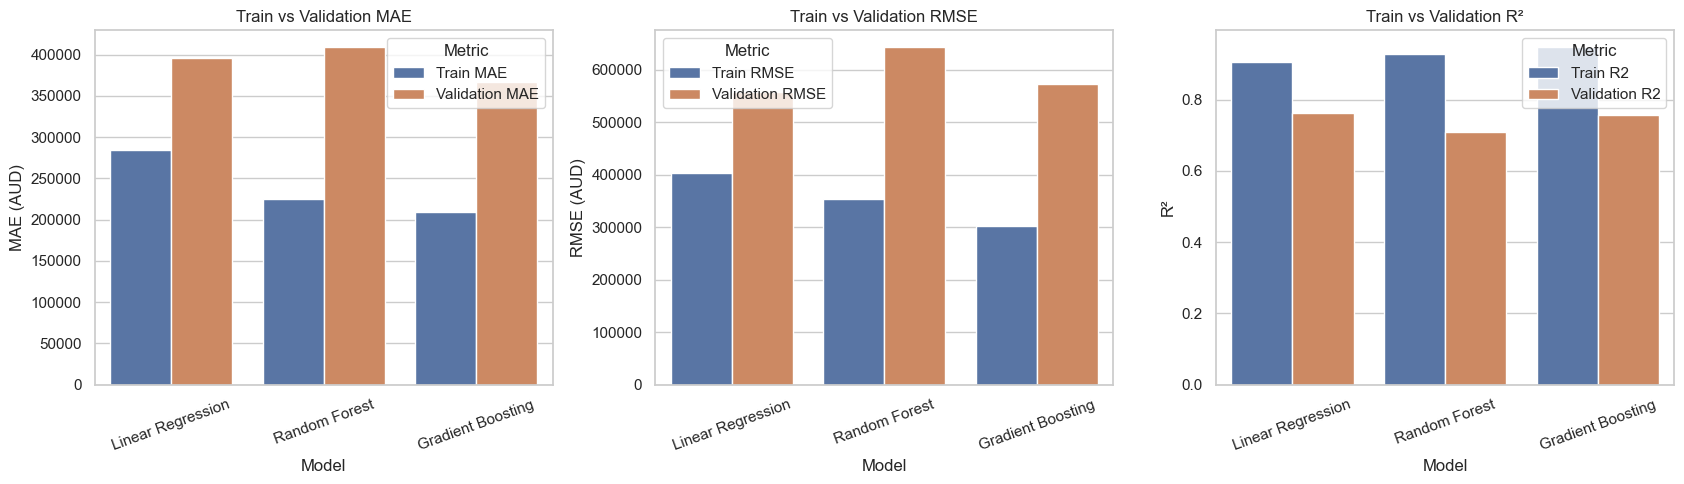

In [44]:
# Compare training and validation performance
comparison_long = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Train MAE",
        "Validation MAE",
        "Train RMSE",
        "Validation RMSE",
        "Train R2",
        "Validation R2"
    ],
    var_name="Metric",
    value_name="Score"
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

mae_data = comparison_long[
    comparison_long["Metric"].isin(["Train MAE", "Validation MAE"])
]
sns.barplot(data=mae_data, x="Model", y="Score", hue="Metric", ax=axes[0])
axes[0].set_title("Train vs Validation MAE")
axes[0].set_ylabel("MAE (AUD)")
axes[0].tick_params(axis="x", rotation=20)

rmse_data = comparison_long[
    comparison_long["Metric"].isin(["Train RMSE", "Validation RMSE"])
]
sns.barplot(data=rmse_data, x="Model", y="Score", hue="Metric", ax=axes[1])
axes[1].set_title("Train vs Validation RMSE")
axes[1].set_ylabel("RMSE (AUD)")
axes[1].tick_params(axis="x", rotation=20)

r2_data = comparison_long[
    comparison_long["Metric"].isin(["Train R2", "Validation R2"])
]
sns.barplot(data=r2_data, x="Model", y="Score", hue="Metric", ax=axes[2])
axes[2].set_title("Train vs Validation R²")
axes[2].set_ylabel("R²")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### Approach and Outcomes: Model Performance and Generalisation

Model performance was evaluated using five-fold cross-validation. The same shuffled folds were applied to all three models to ensure a fair comparison. MAE was used to represent the average absolute prediction error, RMSE gave greater weight to large prediction errors, and R² measured the proportion of sale-price variation explained by each model. Training and validation scores were compared to examine generalisation and identify possible underfitting or overfitting.

Gradient Boosting achieved the lowest validation MAE of $367,374, meaning that it produced the smallest average prediction error. However, Linear Regression achieved the lowest validation RMSE of $558,098 and the highest validation R² of 0.764, compared with an RMSE of $573,253 and R² of 0.758 for Gradient Boosting. This indicates that Linear Regression handled the most substantial prediction errors slightly better and explained approximately 76.4% of the variation in sale prices. Random Forest performed least effectively, with the highest validation MAE ($409,033), highest RMSE ($642,877), and lowest R² (0.710).

All models performed better on the training folds than on the validation folds, indicating some degree of overfitting. Gradient Boosting had the highest training R² (0.947), which decreased to 0.758 during validation. Random Forest declined from 0.929 to 0.710 and showed the largest validation errors, suggesting that its nonlinear complexity did not generalise effectively from this small dataset. Linear Regression showed the smallest R² gap, decreasing from 0.907 to 0.764, and therefore demonstrated the most stable generalisation. None of the models clearly underfit because all achieved strong training R² values above 0.90.

The original expectation that Random Forest would perform best was not supported. Although nonlinear models can capture complex feature interactions, the dataset contains only 100 observations and several sparse suburb–property-type combinations. This limits their ability to learn stable patterns and increases variance. Overall, Linear Regression currently provides the best balance between predictive performance, stability and interpretability, although the final recommendation should also consider fold-level variability and the business cost of different prediction errors.

In [45]:
# Display validation results for each fold
fold_results = []

for model_name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=True
    )

    for fold in range(5):
        fold_results.append({
            "Model": model_name,
            "Fold": fold + 1,
            "Validation MAE": -scores["test_MAE"][fold],
            "Validation RMSE": -scores["test_RMSE"][fold],
            "Validation R2": scores["test_R2"][fold]
        })

fold_results_df = pd.DataFrame(fold_results)

display(
    fold_results_df.round({
        "Validation MAE": 0,
        "Validation RMSE": 0,
        "Validation R2": 3
    })
)

,Model,Fold,Validation MAE,Validation RMSE,Validation R2
0,Linear Regression,1,397718.0,580871.0,0.711
1,Linear Regression,2,359431.0,551812.0,0.875
2,Linear Regression,3,462707.0,654971.0,0.552
3,Linear Regression,4,411836.0,533272.0,0.857
4,Linear Regression,5,346804.0,469563.0,0.822
5,Random Forest,1,443637.0,776480.0,0.484
6,Random Forest,2,370729.0,685745.0,0.808
7,Random Forest,3,262947.0,359742.0,0.865
8,Random Forest,4,559728.0,782956.0,0.691
9,Random Forest,5,408122.0,609463.0,0.701


### Final Evaluation and Model Recommendation

The fold-level results demonstrate that model performance varied according to the composition of each validation subset. Linear Regression produced validation R² values ranging from 0.552 to 0.875, while Random Forest ranged from 0.484 to 0.865 and Gradient Boosting ranged from 0.514 to 0.905. Gradient Boosting achieved the strongest individual result in Fold 3, with an R² of 0.905 and an RMSE of $301,022. However, its performance decreased substantially in other folds, demonstrating sensitivity to the limited sample size and the properties assigned to each fold. Random Forest exhibited similar instability and produced the lowest individual R² of 0.484.

The results demonstrate how model complexity influenced performance. Random Forest and Gradient Boosting were able to fit the training data more closely, but their larger differences between training and validation results indicate greater overfitting. Linear Regression could not represent nonlinear relationships as flexibly, but its simpler structure produced more consistent generalisation. Therefore, increasing model complexity did not produce a clear overall improvement for this dataset.

The initial expectation that Random Forest would perform best was not supported by the experimental results. Gradient Boosting achieved the lowest average validation MAE of $367,374, but Linear Regression achieved the lowest RMSE of $558,098, the highest validation R² of 0.764, and the smallest variability in validation errors. This means Linear Regression was slightly more effective at limiting large prediction errors and produced the most stable performance across the five folds.

Linear Regression is therefore recommended as the most appropriate model for this problem. In addition to its predictive performance, its coefficients can be interpreted to explain how characteristics such as suburb, property type and number of rooms contribute to the predicted sale price. This interpretability is valuable for supporting transparent decisions in a real-estate agency. Nevertheless, the validation RMSE remains approximately $558,000, so predictions should be treated as decision-support estimates rather than exact property valuations. The model should be retrained and reassessed when a larger, more balanced dataset becomes available.


### Part 4: Investigating Prediction Failures

### 15. Identifying the Five Largest Prediction Errors

The final Linear Regression model was used to investigate prediction failures. Out-of-fold predictions were generated using the same five-fold cross-validation method used during model evaluation. This ensures that each property is predicted by a model that was not trained using that property. The absolute difference between the actual and predicted sale price was then calculated, and the five properties with the largest errors were selected for further investigation.

In [46]:
# Import the function used to create cross-validation predictions
from sklearn.model_selection import cross_val_predict

# Create the final Linear Regression pipeline
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Predict each property using five-fold cross-validation
predicted_prices = cross_val_predict(
    final_model,
    X,
    y,
    cv=cv
)

# Create a table for analysing prediction errors
prediction_results = df_fe.copy()

# Add the actual and predicted prices
prediction_results["actual_price"] = y
prediction_results["predicted_price"] = predicted_prices

# Calculate the signed prediction error
prediction_results["prediction_error"] = (
    prediction_results["actual_price"]
    - prediction_results["predicted_price"]
)

# Calculate the error size without considering direction
prediction_results["absolute_error"] = (
    prediction_results["prediction_error"].abs()
)

# Select the five properties with the largest errors
largest_errors = prediction_results.nlargest(
    5,
    "absolute_error"
)

# Select the useful columns to display
columns_to_show = [
    "address",
    "suburb",
    "property_type",
    "bedrooms",
    "bathrooms",
    "parking",
    "land_size",
    "internal_area",
    "actual_price",
    "predicted_price",
    "prediction_error",
    "absolute_error"
]

# Display the results
display(
    largest_errors[columns_to_show].round({
        "actual_price": 0,
        "predicted_price": 0,
        "prediction_error": 0,
        "absolute_error": 0
    })
)

,address,suburb,property_type,bedrooms,bathrooms,parking,land_size,internal_area,actual_price,predicted_price,prediction_error,absolute_error
72,"11 Crick Street, Chatswood",Chatswood,House,5,3,3.0,746.1,NaN,6200000,4459772.0,1740228.0,1740228.0
81,"8 Karana Place, Chatswood",Chatswood,House,4,2,2.0,NaN,NaN,2320000,3895783.0,-1575783.0,1575783.0
44,"5A Gordon Street, Burwood",Burwood,House,3,2,2.0,461.6,NaN,4220000,2661125.0,1558875.0,1558875.0
82,"8 Claude Street, Chatswood",Chatswood,House,3,1,2.0,NaN,NaN,3950000,2528787.0,1421213.0,1421213.0
4,"41 Tully Avenue, Liverpool",Liverpool,House,6,2,2.0,588.1,NaN,1150000,2532878.0,-1382878.0,1382878.0


### 16. Actual versus Predicted Prices

The following chart compares the actual and predicted prices of the five properties with the largest absolute prediction errors. This comparison shows both the size and direction of each error.

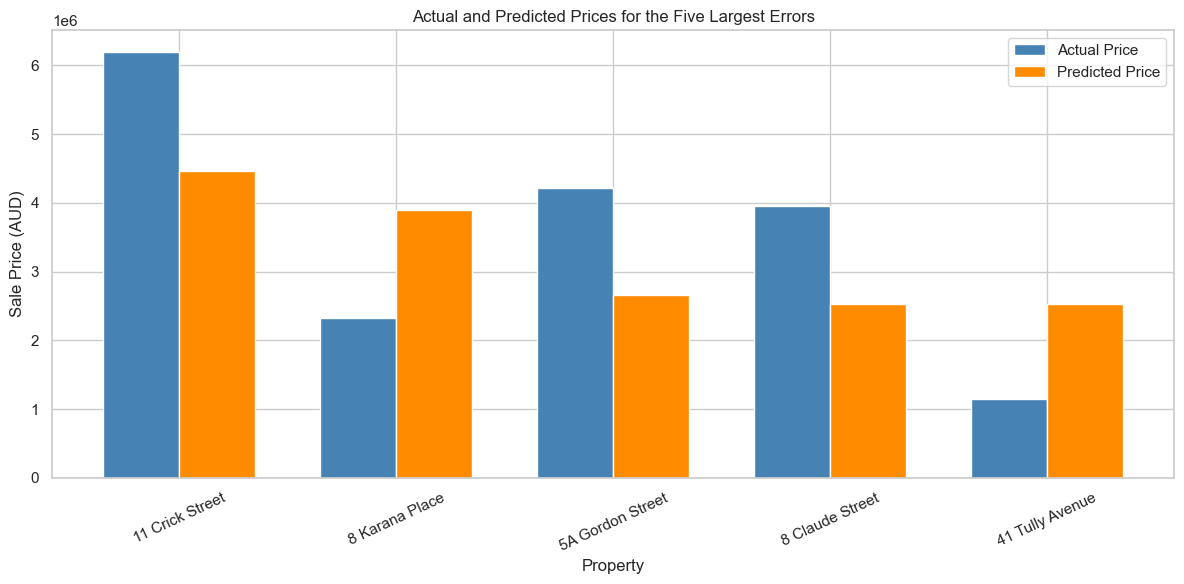

In [47]:
# Prepare the data for the chart
plot_data = largest_errors.copy()

# Use only the street name to make the labels shorter
plot_data["short_address"] = (
    plot_data["address"]
    .str.split(",")
    .str[0]
)

# Create positions for the bars
x = np.arange(len(plot_data))
bar_width = 0.35

# Create the chart
plt.figure(figsize=(12, 6))

plt.bar(
    x - bar_width / 2,
    plot_data["actual_price"],
    width=bar_width,
    label="Actual Price",
    color="steelblue"
)

plt.bar(
    x + bar_width / 2,
    plot_data["predicted_price"],
    width=bar_width,
    label="Predicted Price",
    color="darkorange"
)

# Add chart labels
plt.title("Actual and Predicted Prices for the Five Largest Errors")
plt.xlabel("Property")
plt.ylabel("Sale Price (AUD)")
plt.xticks(x, plot_data["short_address"], rotation=25)
plt.legend()

plt.tight_layout()
plt.show()

### 17. Investigation of Individual Prediction Failures

The five largest errors included three underestimations and two overestimations. This shows that the model did not consistently predict in only one direction. Instead, it experienced difficulty with properties whose prices were unusual compared with other properties having similar recorded characteristics.

**11 Crick Street, Chatswood:** This five-bedroom house sold for $6,200,000, while the model predicted $4,459,772, resulting in an underestimation of $1,740,228. The property has three bathrooms, three parking spaces and 746.1 square metres of land, making it one of the larger houses in the dataset. Although the model recognised several of these valuable characteristics, the actual price was still substantially higher. This may be explained by premium characteristics that were not recorded, such as renovation quality, exact street location, views or luxury finishes.

**8 Karana Place, Chatswood:** This four-bedroom house sold for $2,320,000, but the model predicted $3,895,783. Therefore, the price was overestimated by $1,575,783. Both land size and internal area are missing for this property. The model may have relied strongly on the property being a house in Chatswood with four bedrooms and two bathrooms, resulting in a prediction closer to more expensive Chatswood houses. The missing size information and unavailable details about condition or location limited the model’s ability to distinguish this property from higher-value houses.

**5A Gordon Street, Burwood:** This three-bedroom house sold for $4,220,000, compared with a predicted price of $2,661,125. The model underestimated its value by $1,558,875. Its recorded land size is 461.6 square metres, which does not fully explain its high sale price. The result suggests that the property may have valuable contextual characteristics not included in the dataset, such as a desirable position within Burwood, redevelopment potential, recent renovations or strong buyer competition.

**8 Claude Street, Chatswood:** This three-bedroom house sold for $3,950,000, while its predicted value was $2,528,787. This produced an underestimation of $1,421,213. The land size and internal area are both missing, so the model had limited information about the physical size of the property. The difference may also reflect features that were not collected, including property condition, architectural quality, exact location and access to local services.

**41 Tully Avenue, Liverpool:** This six-bedroom house sold for $1,150,000, but the model predicted $2,532,878, creating an overestimation of $1,382,878. It contains the highest number of bedrooms in the dataset and has 588.1 square metres of land. Because bedrooms had a strong positive relationship with price, the model may have placed too much importance on the six bedrooms. However, the value of additional bedrooms depends on factors such as room size, construction quality, property condition and location. This demonstrates a limitation of assuming that the effect of each additional bedroom is similar across different properties and suburbs.


### 18. Model Limitations and Missing Information

The investigation of the five largest prediction errors revealed several limitations in the modelling approach. First, the dataset contains only 100 properties and is not evenly distributed across suburbs, property types or sale months. As a result, some combinations are represented by many observations, while others contain only one or two properties. This limits the model’s ability to learn reliable patterns for less common properties.

The selected Linear Regression model also assumes that the effects of the predictors are mainly linear and additive. However, property prices may be influenced by more complex relationships. For example, the value of an additional bedroom may differ depending on the suburb, property type, land size and condition of the property. This helps explain why the model produced large errors for unusual properties such as high-value houses and a six-bedroom house in Liverpool.

Missing data was another important limitation. All five properties with the largest errors had missing internal-area values, and two also had missing land-size values. Median imputation allowed the model to generate predictions, but the imputed values do not represent the actual characteristics of these properties. The missing-value indicators preserve some information about the missingness, but they cannot replace the unavailable measurements.

Several important factors that affect housing prices were also unavailable. These include the property’s age, physical condition, renovation quality, exact location, distance from transport and schools, street appeal, development potential and market conditions at the time of sale. Features such as views, floor level and building facilities may also be important for apartments. Access to this information could improve the model’s ability to distinguish between properties with similar recorded features but different sale prices.

Finally, including `suburb`, `property_type` and `suburb_property_type` together introduces some information redundancy. The interaction feature already contains information from the two individual variables. This may create multicollinearity and make the Linear Regression coefficients more difficult to interpret. A future version of the analysis could compare the model with and without the interaction feature or use regularisation methods such as Ridge Regression.


### 19. Cautious Use of Housing Price Predictions

The predicted prices should be treated as estimates rather than exact property valuations. Although Linear Regression achieved the best overall validation RMSE and R², its average validation RMSE was approximately $558,000. The five largest errors were also between approximately $1.38 million and $1.74 million. Therefore, the model may provide useful general guidance, but individual predictions can still differ substantially from the actual sale price.

Predictions should be interpreted particularly carefully when a property has missing information, unusual characteristics or belongs to a category with limited training examples. Luxury properties and properties near the upper end of the market may be underestimated because there are few similar observations in the dataset. The model may also overestimate properties whose recorded characteristics appear valuable but whose price is reduced by factors not included in the data.

All five of the largest prediction failures were houses. This suggests that houses may be more difficult to predict than some other property types in this dataset. Houses can vary considerably in land value, condition, renovation quality and development potential, even when they have similar numbers of bedrooms and bathrooms. However, this result should be interpreted cautiously because houses were also the largest property-type group and were strongly concentrated in Burwood.

The model should not be used as the only basis for lending, investment or property-purchase decisions. Predictions for unusual or high-value properties should be reviewed alongside recent comparable sales and an assessment by a qualified property professional. Future work could also provide prediction intervals to communicate uncertainty instead of presenting only one estimated price.

Overall, the model is most suitable as a decision-support tool for properties that are similar to those represented in the training dataset. Predictions should be treated cautiously when the property is outside the three studied suburbs, belongs to a rare category, contains substantial missing information or is affected by changing market conditions.


### Part 5: Final Deployment and Reflection

### 20. Training and Saving the Final Model

Linear Regression was selected as the final model because it achieved the lowest validation RMSE, the highest validation R² and the most stable performance across the five validation folds. Although Gradient Boosting achieved a lower MAE, Linear Regression was more effective at limiting large prediction errors and was easier to interpret.

For deployment, the preprocessing steps and Linear Regression model were combined into one pipeline. The final pipeline was trained using the complete dataset and saved so that it could be loaded by the web application.

In [48]:
# Import the required tools
import joblib

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression


# Combine preprocessing and Linear Regression
final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)


# Train the final model using all properties
final_model.fit(X, y)


# Information required by the Streamlit application
model_bundle = {
    "model": final_model,
    "dataset_start_date": df["sale_date"].min(),
    "predictor_columns": X.columns.tolist()
}


# Save the complete model bundle
joblib.dump(
    model_bundle,
    "property_price_model.joblib"
)


print("Final model trained successfully.")
print("Model saved as property_price_model.joblib")
print("Number of training properties:", len(X))

Final model trained successfully.
Model saved as property_price_model.joblib
Number of training properties: 100


### 21. Web Application Development

A simple web application was developed using Streamlit to allow users to enter property information and receive an estimated sale price. Streamlit was selected because it provides a simple method for converting a Python machine learning model into an interactive web interface.

The application loads the saved `property_price_model.joblib` file, which contains the fitted preprocessing pipeline and the final Linear Regression model. Saving the complete pipeline ensures that new user inputs receive the same missing-value treatment and categorical encoding that were used during model training.

The interface allows the user to select a suburb and property type and enter the number of bedrooms, bathrooms, parking spaces, land size, internal area and expected sale date. Checkboxes are provided when the land size or internal area is unavailable.

Before prediction, the application creates the same engineered features used during model development. These include `total_rooms`, `months_since_start`, `suburb_property_type`, `land_size_missing` and `internal_area_missing`. The data is then passed to the saved pipeline, which returns the estimated sale price in Australian dollars.

The application also displays a caution message explaining that the prediction is an estimate and should not replace a professional property valuation.


### 22. Application Testing

The application was tested locally through the Streamlit development server. A sample property was entered through the web form, and the application successfully generated an estimated sale price of AUD $2,182,122. This confirmed that the saved model, preprocessing pipeline, engineered features and web interface were working together correctly.

The first screenshot shows the application interface and property input fields. The second screenshot shows the completed prediction and the caution message provided to the user.

**Figure 1. Streamlit application input interface.**

![Streamlit application input interface](app_interface.png)

**Figure 2. Example property price prediction produced by the application.**

![Example property price prediction](app_prediction.png)

## 23. Instructions for Running and Using the Application

The application can be started by opening a terminal in the project folder and running:

```bash
python3 -m streamlit run app.py
```

After the command is executed, the application opens in a web browser using a local address such as `http://localhost:8501`.

To use the application:

1. Select the suburb and property type.
2. Enter the numbers of bedrooms, bathrooms and parking spaces.
3. Enter the land size and internal area. If either value is unavailable, select the relevant checkbox.
4. Select the expected sale date.
5. Click **Predict Sale Price**.
6. Read the estimated sale price displayed in Australian dollars.

The prediction should be treated as an estimate and should not replace a professional property valuation. To stop the application, return to the terminal and press `Control + C`.


### 24. Final Project Reflection

## 24. Final Project Reflection

This project helped me understand the complete machine learning workflow, starting from data collection and finishing with the deployment of a working prediction application. One of the main lessons I learned was that model performance depends greatly on the quality and representativeness of the data. Collecting the housing data manually was time-consuming, and some property advertisements did not provide complete information, especially land size and internal area. This required careful cleaning, missing-value treatment and the creation of missing-value indicators.

During feature engineering, I created features such as `total_rooms`, `months_since_start` and `suburb_property_type`. This showed me that new features can provide useful information, but they may also introduce redundancy or capture sampling patterns rather than genuine market relationships. For example, time and suburb were partly confounded because the three suburbs were not represented equally across the collection period.

The model development stage showed the importance of comparing different approaches rather than assuming that a more complex model will always perform better. Gradient Boosting achieved the lowest validation MAE, while Linear Regression achieved the lowest validation RMSE, the highest validation R² and more stable results across the five folds. Therefore, I selected Linear Regression because it provided a suitable balance between predictive performance, interpretability and practical deployment. Its simpler structure also made it easier to include in the Streamlit application.

There are important limitations and potential biases in this project. The dataset contains only 100 properties from Liverpool, Burwood and Chatswood. Property types and suburbs were not represented equally; for example, houses were strongly concentrated in Burwood, while apartments and units were more common in other suburbs. This means the model may perform better for well-represented properties and may produce less reliable predictions for rare property types. The model should not be applied to properties outside the studied suburbs without further testing. Missing information and unavailable factors such as exact location, property condition, renovation quality, nearby facilities and market conditions may also influence prediction accuracy.

With more time and resources, I would collect a larger and more balanced dataset covering additional suburbs, property types and sale periods. I would also include more detailed location and condition features, test regularised regression methods such as Ridge Regression, tune the models more extensively and provide prediction intervals to communicate uncertainty. Overall, this project demonstrated that building a useful machine learning system requires not only model training, but also careful data preparation, critical evaluation, responsible interpretation and clear communication to users.
